In [1]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("student_performance.csv")
print(df.head())

   student_id  weekly_self_study_hours  attendance_percentage  \
0           1                     18.5                   95.6   
1           2                     14.0                   80.0   
2           3                     19.5                   86.3   
3           4                     25.7                   70.2   
4           5                     13.4                   81.9   

   class_participation  total_score grade  
0                  3.8         97.9     A  
1                  2.5         83.9     B  
2                  5.3        100.0     A  
3                  7.0        100.0     A  
4                  6.9         92.0     A  


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 6 columns):
 #   Column                   Non-Null Count    Dtype  
---  ------                   --------------    -----  
 0   student_id               1000000 non-null  int64  
 1   weekly_self_study_hours  1000000 non-null  float64
 2   attendance_percentage    1000000 non-null  float64
 3   class_participation      1000000 non-null  float64
 4   total_score              1000000 non-null  float64
 5   grade                    1000000 non-null  object 
dtypes: float64(4), int64(1), object(1)
memory usage: 45.8+ MB


In [4]:
df.shape

(1000000, 6)

In [5]:
df.describe()

,student_id,weekly_self_study_hours,attendance_percentage,class_participation,total_score
count,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000
mean,500000.500000,15.029127,84.711046,5.985203,84.283845
std,288675.278933,6.899431,9.424143,1.956421,15.432969
min,1.000000,0.000000,50.000000,0.000000,9.400000
25%,250000.750000,10.300000,78.300000,4.700000,73.900000
50%,500000.500000,15.000000,85.000000,6.000000,87.500000
75%,750000.250000,19.700000,91.800000,7.300000,100.000000
max,1000000.000000,40.000000,100.000000,10.000000,100.000000


In [6]:
df.isnull().sum()

,0
student_id,0
weekly_self_study_hours,0
attendance_percentage,0
class_participation,0
total_score,0
grade,0


In [7]:
print(df.duplicated().sum())
df.drop_duplicates(inplace=True)

0


In [8]:
print(df.dtypes)

student_id                   int64
weekly_self_study_hours    float64
attendance_percentage      float64
class_participation        float64
total_score                float64
grade                       object
dtype: object


In [9]:
print(df["grade"].value_counts())

grade
A    548644
B    258174
C    141980
D     44998
F      6204
Name: count, dtype: int64


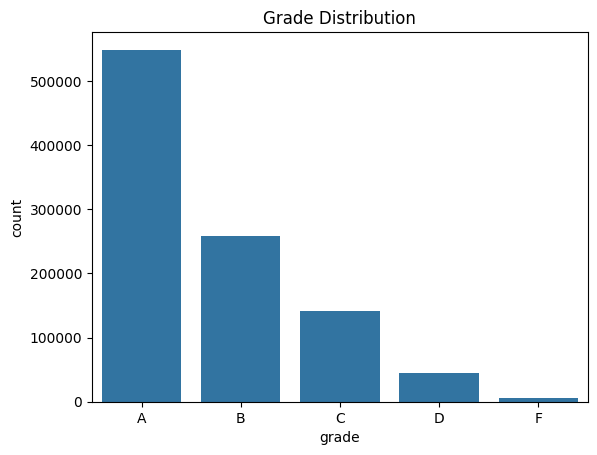

In [10]:
sns.countplot(x="grade", data=df)
plt.title("Grade Distribution")
plt.show()

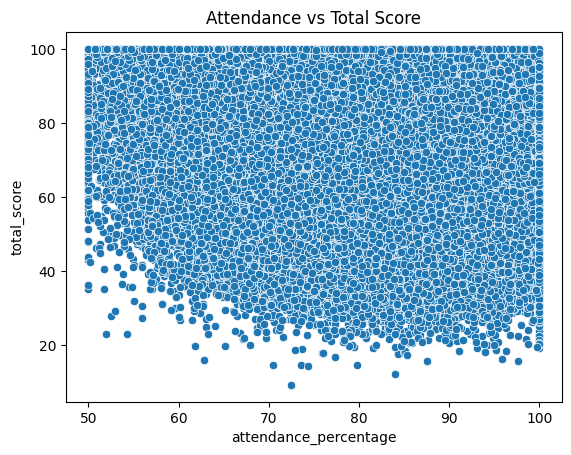

In [11]:
sns.scatterplot(x="attendance_percentage",
                y="total_score",
                data=df)

plt.title("Attendance vs Total Score")
plt.show()

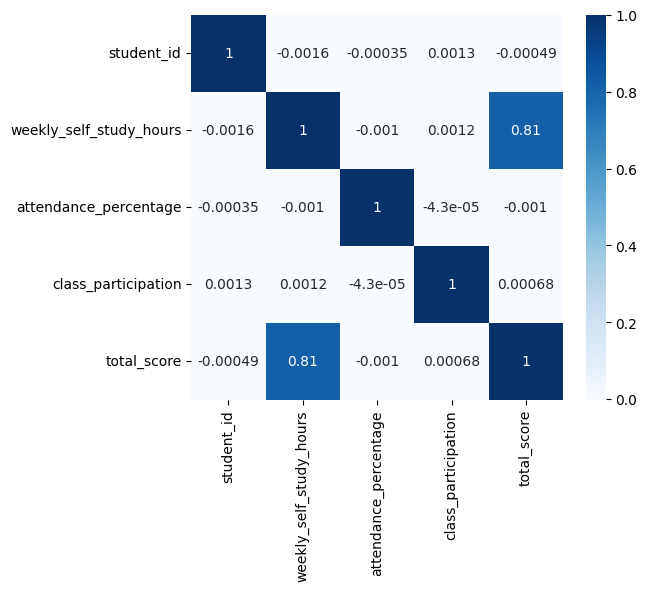

In [12]:
# Correlation
numeric_df = df.select_dtypes(include=np.number)
plt.figure(figsize=(6,5))
sns.heatmap(numeric_df.corr(), annot=True, cmap="Blues")
plt.show()

In [13]:
X = df.drop(["student_id","grade"], axis=1)
y = df["grade"]

In [14]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [15]:
from sklearn.tree import DecisionTreeClassifier
model = DecisionTreeClassifier(random_state=42)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

In [16]:
from sklearn.metrics import accuracy_score
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

Accuracy: 0.998005


In [17]:
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           A       1.00      1.00      1.00    109888
           B       1.00      1.00      1.00     51556
           C       1.00      1.00      1.00     28380
           D       1.00      1.00      1.00      8927
           F       1.00      0.99      0.99      1249

    accuracy                           1.00    200000
   macro avg       1.00      1.00      1.00    200000
weighted avg       1.00      1.00      1.00    200000



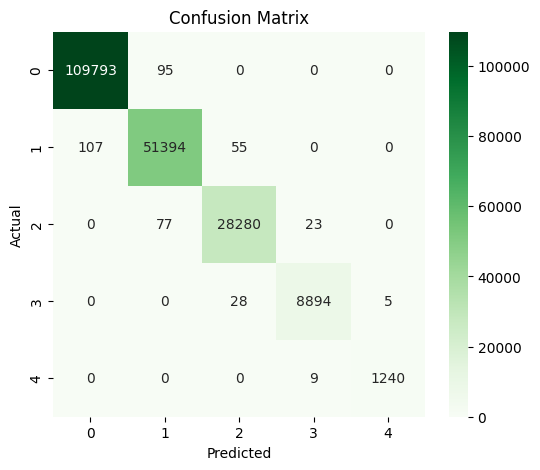

In [18]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm,
            annot=True,
            fmt="d",
            cmap="Greens")

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [19]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": model.feature_importances_
})

importance = importance.sort_values(by="Importance", ascending=False)

print(importance)

                   Feature  Importance
3              total_score    0.996682
1    attendance_percentage    0.001269
0  weekly_self_study_hours    0.001133
2      class_participation    0.000916


In [20]:
risk_students = df[df["total_score"] < 40]
print(risk_students.head())
print("Total At-Risk Students:", len(risk_students))

     student_id  weekly_self_study_hours  attendance_percentage  \
254         255                      4.4                   83.1   
382         383                      0.1                  100.0   
544         545                      0.0                   75.7   
668         669                      0.0                   86.4   
977         978                      0.0                   95.6   

     class_participation  total_score grade  
254                  6.5         38.9     F  
382                  9.0         33.8     F  
544                  6.8         37.8     F  
668                  4.5         34.5     F  
977                  3.0         35.8     F  
Total At-Risk Students: 6131
